In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D  
import figurefirst as fifi
import seaborn as sns
###
import sys
sys.path.insert(1, '../../../Code')
from PlotUtilities import *
from FeatureFunctions import *



from sklearn_genetic import GAFeatureSelectionCV, ExponentialAdapter
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import f_classif
from tsfresh import defaults, extract_features
from tsfresh.feature_selection.relevance import calculate_relevance_table
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import MinimalFCParameters, ComprehensiveFCParameters #
 
import umap


from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from sklearn.preprocessing import StandardScaler
import random


/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?
2025-01-13 16:49:51,725 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-pack

# Set params and load FiFi template

In [2]:
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


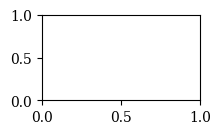

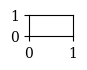

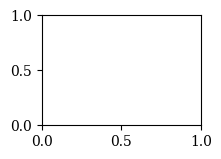

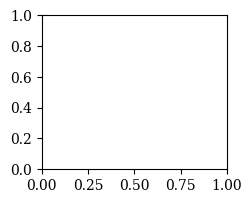

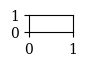

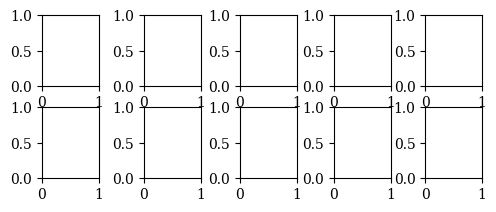

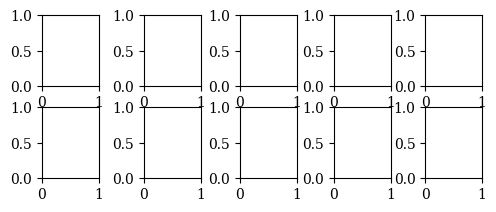

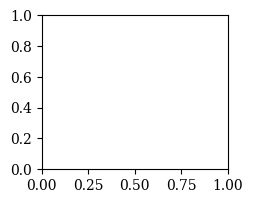

In [62]:
layout = fifi.svg_to_axes.FigureLayout('../S4_feature_selection.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])



# Load data

## Laminar - Control

In [4]:
lam_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/training_laminar_df.hdf')



In [5]:
lam_df = get_normed_positions(lam_df)

## Steady, low

In [6]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')


In [7]:
bottom_on_df['ground speed']= np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)

In [8]:
df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0]
df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0]


In [9]:
flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

## Unsteady, low

In [10]:
top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_top_laminar_09092024.hdf')

In [11]:
top_on_df['ground speed'] = np.sqrt(top_on_df['xvel']**2 + top_on_df['yvel']**2)

In [12]:
df_flash_top_on = top_on_df[top_on_df.duration>0]
df_sham_top_on =top_on_df[top_on_df.duration==0]

In [13]:
flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)


sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

## Still air

In [14]:
nw_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/training_nw_df.hdf')



In [15]:
nw_df = get_normed_positions(nw_df)

# Generate Features

In [16]:
dfs = [lam_df,
       nw_df,
      flash_low_bottom_on, #4: 247
       flash_low_top_on, #5: 128
      flash_up_top_on, #6: 117
    flash_up_bottom_on, #7: 100
      ]


In [17]:
dfs = calculate_features(dfs, start_time=1100)

df # 0
Culled 6 trajectories
n trajs: 312
df # 1
Culled 1 trajectories
n trajs: 251
df # 2
Culled 45 trajectories
n trajs: 255
df # 3
Culled 88 trajectories
n trajs: 231
df # 4
Culled 20 trajectories
n trajs: 115
df # 5
Culled 7 trajectories
n trajs: 99


In [18]:
all_dfs = pd.concat(dfs)

### Assign df names + colors + generate some custom features

In [19]:
df_features_list = []


cmap_real = plt.get_cmap('RdBu', 16) 


#  Steady: real -> Blues; sim -> green
# Unsteady: real -> orange; sim -> pink/brown
'''
df_colors = [cmap_real(3),
             cmap_real(14),

             'darkorange',
            cmap_real(13),
             cmap_real(4),
            cmap_real(12),]

'''


df_colors = [cmap_real(1),
             cmap_real(15),

             'darkorange',
            cmap_real(13),
             cmap_real(3),
            cmap_real(11),]





df_labels = ['Laminar', #0
             'Still Air', #1
             'Steady, z < 0.25m', #2
             'Unsteady, z < 0.25m', #3
             'Steady, z > 0.25m', #4
             'Unsteady, z > 0.25m', #5
            ]

df_features_list = []



feature_names = ['circle_cross', 
                 'hull_area', 
                 'hull_roundness', 

                 'heading_derivative_absmean',
                 'heading_difference_sliding_absmean',]


for i, df in enumerate(dfs):
    df['dataset_name'] = df_labels[i]
    
    #df =df.assign(color=df.apply(lambda x: df_colors[i], 1))
    df_features = df.groupby('obj_id_unique')['dataset_name'].first()
    
    
    for feature_name in feature_names:
        df_tmp = np.abs( df.groupby('obj_id_unique')[feature_name].mean() )
        df_features = pd.concat([df_features, df_tmp], axis=1)
    df_features['class']=i
    df_features =df_features.assign(color=df_features.apply(lambda x: df_colors[i], 1))
    df_features_list.append(df_features)
    
df_features = pd.concat(df_features_list)

# Comprehensive Feature Set

In [20]:
X_comp = extract_features(all_dfs[['xvel','yvel', 'normed_x_680', 'normed_y_680','obj_id_unique','time stamp']].dropna(), 
                         column_id='obj_id_unique', column_sort='time stamp',
                         default_fc_parameters=ComprehensiveFCParameters(),
                     impute_function=impute)

# these are just the length of each time series, not relevant features
X_comp = X_comp.drop(columns=['xvel__length','yvel__length','normed_x_680__length','normed_y_680__length'])


2025-01-13 16:51:11,858 [WARNING] Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100%|██████████████████████████████████████████████████████████| 80/80 [00:51<00:00,  1.55it/s]


In [21]:

comprehensive_df= df_features.join(X_comp)

### Mann-Whitney U test

In [22]:
# reduce features by Mann-Whitney U test + remove repetitive features
training_data =comprehensive_df[comprehensive_df.dataset_name.isin(['Laminar', 'Still Air',])].drop(columns=['dataset_name', 'color','class',]).sort_index()#+ irrel_mann)#+ irrel_feats)
y_classes =  comprehensive_df[comprehensive_df.dataset_name.isin(['Laminar', 'Still Air',])]['class'].sort_index() 
y_colors =  comprehensive_df[comprehensive_df.dataset_name.isin(['Laminar', 'Still Air',])]['color'] .sort_index() 

df_pvalues_mann = calculate_relevance_table(training_data,y_classes, fdr_level=0.05, hypotheses_independent=False)
irrel_feats_mannu=list(df_pvalues_mann [df_pvalues_mann["relevant"] == False].feature.values)
#training_data_reduced = cull_repetitive_features(training_data[list(df_pvalues_mann.feature[df_pvalues_mann["relevant"] == True])].sort_index())




In [23]:
training_data_reduced= training_data[list(df_pvalues_mann.feature[df_pvalues_mann["relevant"] == True])].sort_index()

### Genetic Algorithm

In [24]:

X1_values =training_data_reduced.values
X1_features = training_data_reduced.columns
y_classes =  comprehensive_df[comprehensive_df.dataset_name.isin(['Laminar', 'Still Air',])]['class'].sort_index() 

#split into training + testing data
X_train, X_test, y_train, y_test = train_test_split(X1_values, y_classes, test_size=0.33, random_state=100)
X_train1 = StandardScaler().fit_transform(X_train)
X_test1 = StandardScaler().fit_transform(X_test)

In [25]:
# Train and select the features
np.random.seed(100)
random.seed(100)
clf =  GaussianNB()
mutation_scheduler = ExponentialAdapter(0.8, 0.2, 0.01)
crossover_scheduler = ExponentialAdapter(0.2, 0.8, 0.01)
cv = StratifiedKFold(n_splits=3, random_state=100, shuffle=True)

evolved_estimator = GAFeatureSelectionCV(
    estimator=clf,
    cv=cv,
    scoring="accuracy",
    population_size=500,
    generations=50,
    mutation_probability=mutation_scheduler,
    crossover_probability=crossover_scheduler,
    n_jobs=-1, max_features=100 )

evolved_estimator.fit(X_train1, y_train)


gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	500   	-44799.5	49729.3    	0.932796   	-100000    
1  	1000  	-40399.5	49070.2    	0.927419   	-100000    
2  	1000  	-37199.4	48334.3    	0.922043   	-100000    
3  	1000  	-37199.4	48334.3    	0.924731   	-100000    
4  	1000  	-38399.5	48636.2    	0.922043   	-100000    
5  	1000  	-40799.5	49146.7    	0.924731   	-100000    
6  	1000  	-42599.5	49449.8    	0.922043   	-100000    
7  	1000  	-42199.5	49388.3    	0.922043   	-100000    
8  	1000  	-47599.5	49942.8    	0.924731   	-100000    
9  	1000  	-46599.5	49884.7    	0.930108   	-100000    
10 	1000  	-44999.5	49749.8    	0.930108   	-100000    
11 	1000  	-41799.5	49323.5    	0.930108   	-100000    
12 	1000  	-39999.5	48990.2    	0.930108   	-100000    
13 	1000  	-40199.5	49030.6    	0.935484   	-100000    
14 	1000  	-42599.5	49449.8    	0.935484   	-100000    
15 	1000  	-42799.5	49479.3    	0.935484   	-100000    
16 	1000  	-41199.5	49220      	0.935484   	-100

GAFeatureSelectionCV(crossover_probability=<sklearn_genetic.schedules.schedulers.ExponentialAdapter object at 0x7f7e79eb7510>,
                     cv=StratifiedKFold(n_splits=3, random_state=100, shuffle=True),
                     estimator=GaussianNB(), generations=50, max_features=100,
                     mutation_probability=<sklearn_genetic.schedules.schedulers.ExponentialAdapter object at 0x7f7e79eb6d10>,
                     n_jobs=-1, population_size=500, scoring='accuracy')

In [26]:
# Features selected by the algorithm
features = evolved_estimator.best_features_
training_data_reduced1 = training_data_reduced[list(X1_features[features])].sort_index()
training_data_reduced1['dataset_name'] = comprehensive_df.dataset_name.sort_index()
training_data_reduced1['color'] = comprehensive_df.color.sort_index()

### Bootstrap Bayes Classifier

In [27]:
classifications1=[]
gnb =  GaussianNB()
for i in range(10000):
    X_train, X_test, y_train, y_test = train_test_split( training_data_reduced[list(X1_features[features])].sort_index().values, y_classes, test_size=0.2, random_state=i)
    y_pred = gnb.fit(X_train, y_train).predict(X_test)
    classifications1.append((y_test != y_pred).sum()/X_test.shape[0])

Mean error: 0.05235357142857144


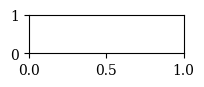

In [63]:
hist_factor = -2.
binwidth = 30

fig,ax = plt.subplots(figsize= (2,.5))
ax = layout.axes[('B2', 'b2')]
binlist = range(int(min(classifications1)), int(max(classifications1))+binwidth, binwidth)
ax.hist(classifications1, bins = 50, color = 'k', weights=(10**hist_factor)*np.ones_like(classifications1), histtype = 'step',)
ax.set_xlim(0, 0.15)

print('Mean error:', np.mean(classifications1))
fifi.mpl_functions.adjust_spines(ax, ['bottom'], xticks =[0,0.25],  spine_locations={'bottom':5, }, tick_length=3, linewidth=.5)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.set_xticklabels(['0','0.15'])
layout.append_figure_to_layer(layout.figures['B2'], 'B2', cleartarget=True)

### Train UMAP

In [52]:
trained_model = umap.UMAP(n_neighbors=25, min_dist=0,
    random_state=10, transform_seed=42).fit(StandardScaler().fit_transform(training_data_reduced1.drop(columns=['dataset_name','color']).values) )

#30000

/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


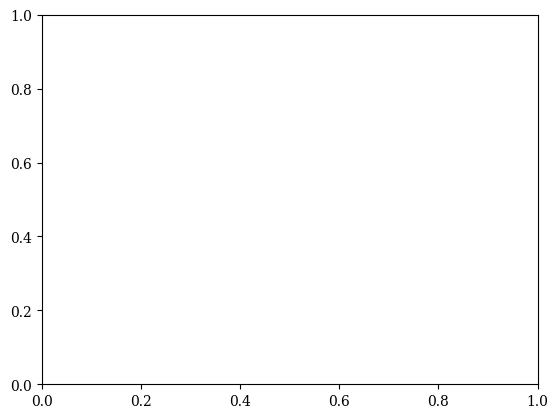

In [64]:
fig,ax=plt.subplots()

ax = layout.axes[('B1', 'b1')]
sns.kdeplot(x=trained_model.embedding_[:,1], y=trained_model.embedding_[:, 0], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

ax.scatter(trained_model.embedding_[:,1],trained_model.embedding_[:, 0], s= 1, c=y_colors,)


legend_labels=[]
legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=training_data_reduced1[training_data_reduced1.dataset_name=='Laminar'].color.iloc[0], markerfacecolor=training_data_reduced1[training_data_reduced1.dataset_name=='Laminar'].color.iloc[0], linestyle='', label=training_data_reduced1[training_data_reduced1.dataset_name=='Laminar'].dataset_name.iloc[0]))
legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=training_data_reduced1[training_data_reduced1.dataset_name=='Still Air'].color.iloc[0], markerfacecolor=training_data_reduced1[training_data_reduced1.dataset_name=='Still Air'].color.iloc[0], linestyle='', label=training_data_reduced1[training_data_reduced1.dataset_name=='Still Air'].dataset_name.iloc[0]))


#ax.legend(loc='lower left', handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
#ax.set_xlim(4,14)
#ax.set_ylim(7,13)


ax.set_aspect('equal')
#ax = layout.axes[('E1', 'e1')]
ax.set_rasterized(True)
ax.axis('off')
fifi.mpl_functions.set_fontsize(ax, 6)
layout.append_figure_to_layer(layout.figures['B1'], 'B1', cleartarget=True)

### Project steady + unsteady data

In [65]:
df_gafeats = comprehensive_df[comprehensive_df.columns[comprehensive_df.columns.isin(list(training_data_reduced1.columns))]]
X_test = df_gafeats [df_gafeats .dataset_name.isin(['Steady, z < 0.25m', 'Unsteady, z < 0.25m', 'Steady, z > 0.25m',
       'Unsteady, z > 0.25m', ])].drop(columns=['dataset_name', 'color',]).sort_index()#+ irrel_mann )#+irrel_feats_lam)
X_test  =StandardScaler().fit_transform(X_test.values)

y_test =  df_gafeats [df_gafeats .dataset_name.isin(['Steady, z < 0.25m', 'Unsteady, z < 0.25m', 'Steady, z > 0.25m',
       'Unsteady, z > 0.25m', ])]['color'].sort_index() 

test_embedding = trained_model.transform(X_test)
plottingdf = df_gafeats[df_gafeats.dataset_name.isin([ 'Steady, z < 0.25m', 'Unsteady, z < 0.25m', 'Steady, z > 0.25m',
       'Unsteady, z > 0.25m', ])].sort_index().copy()#.drop(columns=['dataset_name', 'color','class', ]+ irrel_feats+irrel_feats_lam).copy()
plottingdf['embedding_x'] = test_embedding[:, 1]
plottingdf['embedding_y'] =test_embedding[:, 0]


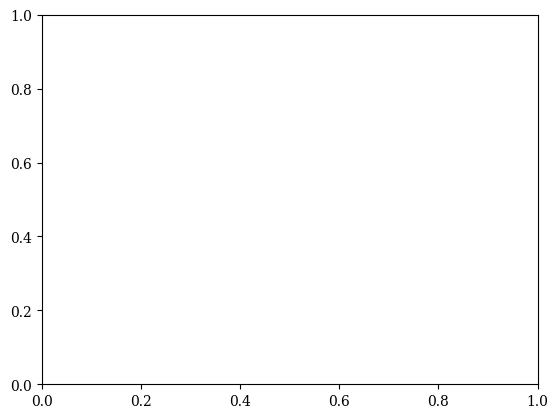

In [66]:

fig, ax = plt.subplots()

ax = layout.axes[('I2', 'i2')]
sns.kdeplot(x=trained_model.embedding_[:, 1], y=trained_model.embedding_[:, 0], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

for i in plottingdf['dataset_name'].unique():
    if "z > 0.25" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color, marker='d')
        legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    if "z < 0.25" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color)
        legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    
    
    #legend_labels.append(mpatches.Patch(color=plottingdf[plottingdf['class']==i].color.iloc[0], label=plottingdf[plottingdf['class']==i]['dataset_name'].iloc[0]))

#ax.set_xlim(4,14)
#ax.set_ylim(7,13)
ax.set_aspect('equal')

ax.set_rasterized(True)
#ax.legend(bbox_to_anchor=[0.85,0.1], handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')
layout.append_figure_to_layer(layout.figures['I2'], 'I2', cleartarget=True)


### Look at top 10 features

In [33]:
# Perform ANOVA F-test
f_values, p_values = f_classif(df_gafeats [df_gafeats .dataset_name.isin(['Laminar','Still Air', ])].drop(columns=['dataset_name', 'color',]).sort_index(), y_classes.sort_index(),)
sig_test_df = pd.DataFrame([ df_gafeats [df_gafeats .dataset_name.isin(['Laminar','Still Air', ])].drop(columns=['dataset_name', 'color',]).columns, f_values, p_values]).T.rename(columns={0:'feature',1:'f_stat', 2:'p_val'})
sig_test_df = sig_test_df.sort_values(by='f_stat',ascending=False)


normed_x_680__number_crossing_m__m_0
normed_x_680__quantile__q_0.4
normed_x_680__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)
normed_x_680__cwt_coefficients__coeff_5__w_2__widths_(2, 5, 10, 20)
normed_x_680__quantile__q_0.1
normed_x_680__cwt_coefficients__coeff_10__w_10__widths_(2, 5, 10, 20)
circle_cross
xvel__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.2
normed_x_680__binned_entropy__max_bins_10
yvel__approximate_entropy__m_2__r_0.5


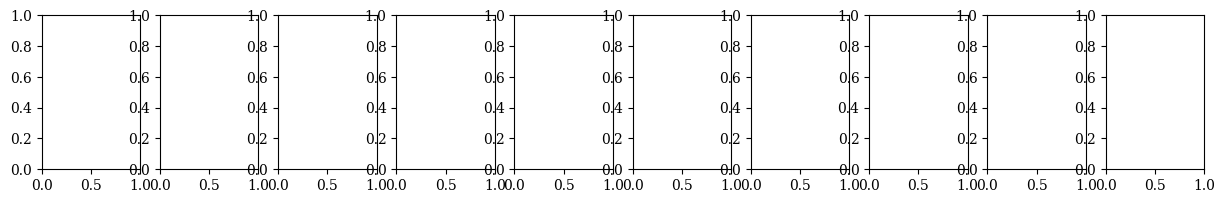

In [67]:
cmap_real = plt.get_cmap('RdBu', 16) 



df_colors = [cmap_real(3),
             cmap_real(14),]

dfss = [comprehensive_df[comprehensive_df['class']==0], comprehensive_df[comprehensive_df['class']==1]]

df_labels=['lam-control','nw-control', ]
fig, ax = plt.subplots(ncols=10, figsize=(15,2))

ax[0] = layout.axes[('D', 'd1')]
ax[1] = layout.axes[('D', 'd2')]
ax[2] = layout.axes[('D', 'd3')]
ax[3] = layout.axes[('D', 'd4')]
ax[4] = layout.axes[('D', 'd5')]
ax[5] = layout.axes[('D', 'd6')]
ax[6] = layout.axes[('D', 'd7')]
ax[7] = layout.axes[('D', 'd8')]
ax[8] = layout.axes[('D', 'd9')]
ax[9] = layout.axes[('D', 'd10')]



for i, feat in enumerate(sig_test_df.feature[0:10]):
    plot_feature(dfss, feat, ax=ax[i],  df_colors=df_colors)
    print(feat)
    
layout.append_figure_to_layer(layout.figures['D'], 'D', cleartarget=True)
    
    

In [77]:
np.max(classifications)

0.16071428571428573

# Simple feature set

In [36]:
X_simple = extract_features(all_dfs[['xvel','yvel', 'normed_x_680', 'normed_y_680','obj_id_unique','time stamp']].dropna(), 
                         column_id='obj_id_unique', column_sort='time stamp',
                         default_fc_parameters=MinimalFCParameters(),
                     impute_function=impute)

# these are just the length of each time series, not relevant features
X_simple = X_simple.drop(columns=['xvel__length','yvel__length','normed_x_680__length','normed_y_680__length'])


2025-01-13 18:25:10,128 [WARNING] Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100%|█████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 119.63it/s]


In [37]:

simple_df= df_features.join(X_simple)

### Mann Whitney U test

In [38]:
training_data_simple = simple_df[simple_df.dataset_name.isin(['Laminar', 'Still Air',])].drop(columns=['dataset_name', 'color','class',]).sort_index()
y_classes_simple = simple_df[simple_df.dataset_name.isin(['Laminar', 'Still Air',])]['class'].sort_index() 
y_colors_simple = simple_df[simple_df.dataset_name.isin(['Laminar', 'Still Air',])]['color'] .sort_index() 
df_pvalues_mann_simple = calculate_relevance_table(training_data_simple,y_classes_simple, fdr_level=0.05, hypotheses_independent=False)
irrel_feats_mannu_simple=list(df_pvalues_mann_simple [df_pvalues_mann_simple['p_value']>0.05].feature.values)

# remove irrel feats
training_data_simple = simple_df[simple_df.dataset_name.isin(['Laminar', 'Still Air',])].drop(columns=['dataset_name', 'color','class',]+irrel_feats_mannu_simple).sort_index()


### Bootstrap Bayes Test

In [39]:
classifications=[]
gnb =  GaussianNB()
for i in range(10000):
    X_train, X_test, y_train, y_test = train_test_split(training_data_simple.values, y_classes_simple, test_size=0.2, random_state=i)
    y_pred = gnb.fit(X_train, y_train).predict(X_test)
    classifications.append((y_test != y_pred).sum()/X_test.shape[0])

Mean error: 0.07050178571428571


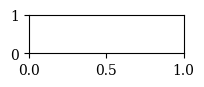

In [68]:
hist_factor = -2.
binwidth = 30

fig,ax = plt.subplots(figsize= (2,.5))
ax = layout.axes[('A2', 'a2')]
binlist = range(int(min(classifications)), int(max(classifications))+binwidth, binwidth)
ax.hist(classifications, bins = 50, color = 'k', weights=(10**hist_factor)*np.ones_like(classifications), histtype = 'step',)
ax.set_xlim(0, 0.15)

print('Mean error:', np.mean(classifications))
fifi.mpl_functions.adjust_spines(ax, ['bottom'], xticks =[0,0.25],  spine_locations={'bottom':5, }, tick_length=3, linewidth=.5)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.set_xticklabels(['0','0.15'])
layout.append_figure_to_layer(layout.figures['A2'], 'A2', cleartarget=True)

### train UMAP

In [69]:
trained_model = umap.UMAP(n_neighbors=25, min_dist=0,
    random_state=3000, transform_seed=42).fit(StandardScaler().fit_transform(training_data_simple.values) )

#30000

/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


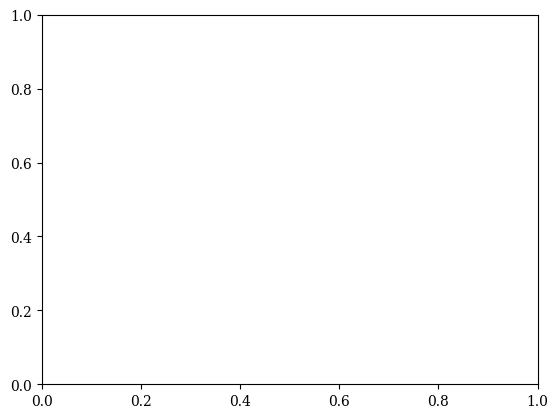

In [70]:
fig,ax=plt.subplots()
ax = layout.axes[('A1', 'a1')]
#sns.kdeplot(x=trained_model.embedding_[:, 0], y=trained_model.embedding_[:, 1], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), ax=ax)
sns.kdeplot(x=trained_model.embedding_[:, 0], y=trained_model.embedding_[:, 1], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

ax.scatter(trained_model.embedding_[:, 0],trained_model.embedding_[:, 1], s= 1, c=y_colors,)


legend_labels=[]
legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=simple_df[simple_df.dataset_name=='Laminar'].sort_index().color.iloc[0], markerfacecolor=simple_df[simple_df.dataset_name=='Laminar'].color.iloc[0], linestyle='', label=simple_df[simple_df.dataset_name=='Laminar'].sort_index().dataset_name.iloc[0]))
legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=simple_df[simple_df.dataset_name=='Still Air'].sort_index().color.iloc[0], markerfacecolor=simple_df[simple_df.dataset_name=='Still Air'].color.iloc[0], linestyle='', label=simple_df[simple_df.dataset_name=='Still Air'].sort_index().dataset_name.iloc[0]))


#ax.legend(bbox_to_anchor=[0.85,0.1], handles=legend_labels)
#ax.set_xlim(2,13)
#ax.set_ylim(7,13)

#ax.axis('off')
ax.set_aspect('equal')
ax.set_rasterized(True)
ax.axis('off')
fifi.mpl_functions.set_fontsize(ax, 6)
layout.append_figure_to_layer(layout.figures['A1'], 'A1', cleartarget=True)

### Project unsteady + steady data

In [71]:
X_test = simple_df[simple_df.dataset_name.isin(['Steady, z < 0.25m', 'Unsteady, z < 0.25m', 'Steady, z > 0.25m','Unsteady, z > 0.25m', ])].drop(columns=['dataset_name', 'color','class',]+ irrel_feats_mannu_simple).sort_index()
X_test  =StandardScaler().fit_transform(X_test.values)

y_test =  simple_df[simple_df.dataset_name.isin(['Steady, z < 0.25m', 'Unsteady, z < 0.25m', 'Steady, z > 0.25m','Unsteady, z > 0.25m', ])]['color'].sort_index()

test_embedding = trained_model.transform(X_test)

plottingdf = simple_df[simple_df.dataset_name.isin([ 'Steady, z < 0.25m', 'Unsteady, z < 0.25m', 'Steady, z > 0.25m',
       'Unsteady, z > 0.25m', ])].sort_index().copy()#.drop(columns=['dataset_name', 'color','class', ]+ irrel_feats+irrel_feats_lam).copy()
plottingdf['embedding_x'] = test_embedding[:, 0]
plottingdf['embedding_y'] =test_embedding[:, 1]

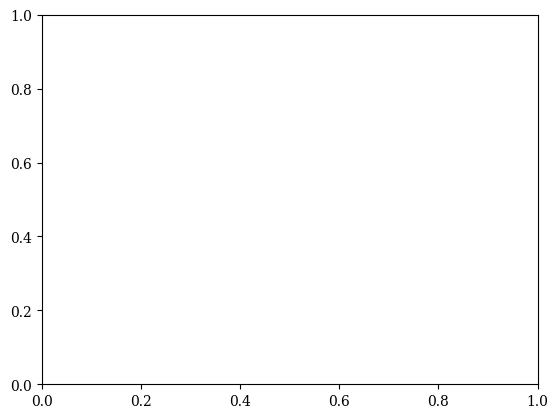

In [72]:

fig, ax = plt.subplots()

ax = layout.axes[('I1', 'i1')]
sns.kdeplot(x=trained_model.embedding_[:, 0], y=trained_model.embedding_[:, 1], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

for i in plottingdf['dataset_name'].unique():
    if "z > 0.25" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color, marker='d')
        legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    if "z < 0.25" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color)
        legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))

ax.set_aspect('equal')

ax.set_rasterized(True)
#ax.legend(bbox_to_anchor=[0.85,0.1], handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')
layout.append_figure_to_layer(layout.figures['I1'], 'I1', cleartarget=True)


### Look at top 10 features

In [45]:

# Perform ANOVA F-test
f_values_s, p_values_s = f_classif(training_data_simple, y_classes_simple,)
sig_test_df_simple = pd.DataFrame([ training_data_simple.columns, f_values_s, p_values_s]).T.rename(columns={0:'feature',1:'f_stat', 2:'p_val'})

sig_test_df_simple = sig_test_df_simple.sort_values(by='f_stat',ascending=False)


normed_x_680__median
normed_x_680__mean
normed_x_680__sum_values
xvel__standard_deviation
normed_x_680__minimum
circle_cross
xvel__variance
xvel__root_mean_square
normed_x_680__maximum
normed_x_680__root_mean_square


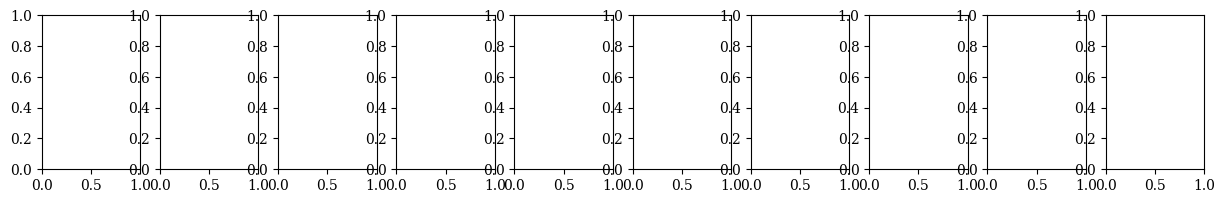

In [73]:
cmap_real = plt.get_cmap('RdBu', 16) 


df_colors = [cmap_real(3),
             cmap_real(14),]

dfss = [simple_df[simple_df['class']==0], simple_df[simple_df['class']==1]]

df_labels=['lam-control','nw-control', ]
fig, ax = plt.subplots(ncols=10, figsize=(15,2))
ax[0] = layout.axes[('C', 'c1')]
ax[1] = layout.axes[('C', 'c2')]
ax[2] = layout.axes[('C', 'c3')]
ax[3] = layout.axes[('C', 'c4')]
ax[4] = layout.axes[('C', 'c5')]
ax[5] = layout.axes[('C', 'c6')]
ax[6] = layout.axes[('C', 'c7')]
ax[7] = layout.axes[('C', 'c8')]
ax[8] = layout.axes[('C', 'c9')]
ax[9] = layout.axes[('C', 'c10')]


for i, feat in enumerate(sig_test_df_simple.feature[0:10]):
    plot_feature(dfss, feat, ax=ax[i], df_colors=df_colors) 
    print(feat)
    
layout.append_figure_to_layer(layout.figures['C'], 'C', cleartarget=True)
    
    

# Save Figure

In [74]:
layout.write_svg('S4_features.svg')